In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])
df = df.drop('customerID', axis=1)

X = df.drop('Churn', axis=1)
y = df['Churn'].map({'No': 0, 'Yes': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
categorical_features = [col for col in X.columns if col not in numeric_features]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

print("Ready — train:", X_train.shape, "test:", X_test.shape)

Ready — train: (5625, 19) test: (1407, 19)


In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42)
}

results = []

In [6]:
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Recall (Churn)': rec,
        'False Negatives': cm[1][0],
        'False Positives': cm[0][1]
    })
    
    print(f"\n{name}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Recall:   {rec:.4f}")
    print(f"  CM: {cm.tolist()}")

results_df = pd.DataFrame(results)
print("\n\nSummary:")
print(results_df)


Logistic Regression
  Accuracy: 0.7264
  Recall:   0.7941
  CM: [[725, 308], [77, 297]]



Random Forest
  Accuracy: 0.7839
  Recall:   0.4733
  CM: [[926, 107], [197, 177]]

Gradient Boosting
  Accuracy: 0.7932
  Recall:   0.5321
  CM: [[917, 116], [175, 199]]


Summary:
                 Model  Accuracy  Recall (Churn)  False Negatives  \
0  Logistic Regression  0.726368        0.794118               77   
1        Random Forest  0.783937        0.473262              197   
2    Gradient Boosting  0.793177        0.532086              175   

   False Positives  
0              308  
1              107  
2              116  


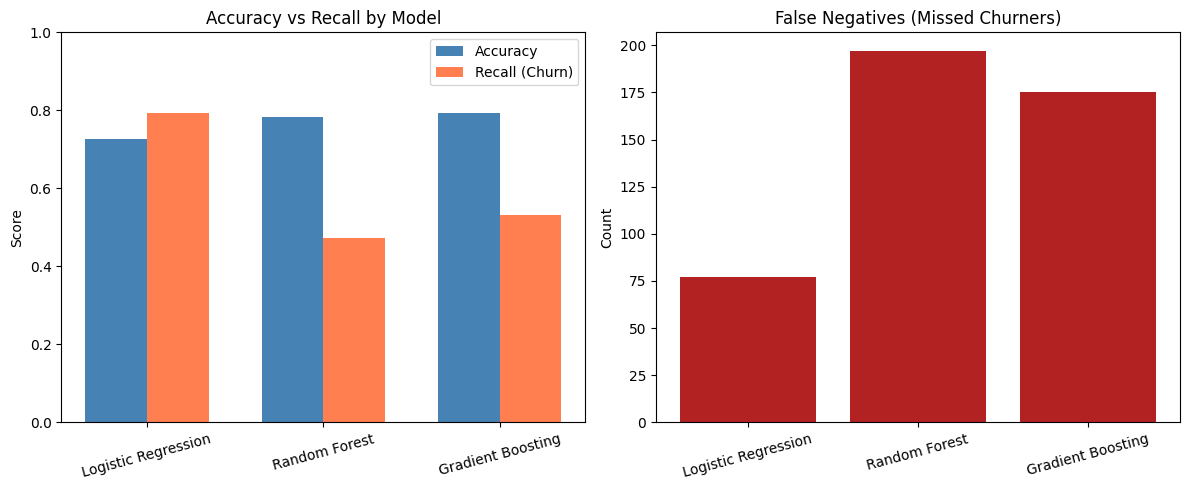

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy vs Recall
x = np.arange(len(results_df))
width = 0.35

axes[0].bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
axes[0].bar(x + width/2, results_df['Recall (Churn)'], width, label='Recall (Churn)', color='coral')
axes[0].set_ylabel('Score')
axes[0].set_title('Accuracy vs Recall by Model')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=15)
axes[0].legend()
axes[0].set_ylim(0, 1)

# False Negatives (missed churners)
axes[1].bar(results_df['Model'], results_df['False Negatives'], color='firebrick')
axes[1].set_ylabel('Count')
axes[1].set_title('False Negatives (Missed Churners)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()